## CME NOV 2025

In [1]:
import pandas as pd
import numpy as np

cme_nov_2025 = pd.read_csv("../../data/raw/CME/CME_NOV_2025.csv")
cme_nov_2025 = cme_nov_2025.reset_index(drop = True)
cme_nov_2025["time"] = pd.to_datetime(cme_nov_2025["time"],unit="s") 

In [2]:
cme_nov_2025

,time,open,high,low,close,Volume
0,2025-07-16 18:59:00,95.9550,95.9550,95.9550,95.9550,1434
1,2025-07-16 19:00:00,95.9550,95.9550,95.9550,95.9550,1
2,2025-07-16 19:02:00,95.9550,95.9550,95.9550,95.9550,832
3,2025-07-16 19:12:00,95.9550,95.9550,95.9550,95.9550,40
4,2025-07-16 19:13:00,95.9550,95.9550,95.9550,95.9550,32
...,...,...,...,...,...,...
19994,2025-11-27 23:04:00,96.1225,96.1225,96.1225,96.1225,8
19995,2025-11-28 15:31:00,96.1250,96.1250,96.1250,96.1250,15
19996,2025-11-28 15:43:00,96.1225,96.1225,96.1225,96.1225,63
19997,2025-11-28 16:50:00,96.1225,96.1225,96.1225,96.1225,3


## CME DEC 2025

In [3]:
cme_dec_2025 = pd.read_csv("../../data/raw/CME/CME_DEC_2025.csv")
cme_dec_2025 = cme_dec_2025.reset_index(drop = True)
cme_dec_2025["time"] = pd.to_datetime(cme_dec_2025["time"],unit="s") 

In [4]:
cme_dec_2025

,time,open,high,low,close,Volume
0,2025-07-30 20:27:00,95.9900,95.9900,95.9900,95.9900,33
1,2025-07-30 20:29:00,95.9850,95.9850,95.9850,95.9850,10
2,2025-07-30 20:56:00,95.9850,95.9850,95.9850,95.9850,48
3,2025-07-30 20:58:00,95.9850,95.9850,95.9850,95.9850,21
4,2025-07-30 22:00:00,95.9800,95.9800,95.9750,95.9750,8
...,...,...,...,...,...,...
19994,2025-12-31 13:39:00,96.2800,96.2800,96.2800,96.2800,2
19995,2025-12-31 14:30:00,96.2775,96.2775,96.2775,96.2775,1
19996,2025-12-31 15:11:00,96.2800,96.2800,96.2800,96.2800,4
19997,2025-12-31 18:09:00,96.2800,96.2800,96.2800,96.2800,1


## Merge and then calculate probabilities

In [5]:
nov = cme_nov_2025.copy()
nov["time"] = pd.to_datetime(nov["time"], unit="s")
nov = nov.sort_values("time").set_index("time")

nov = nov.add_suffix("_nov_2025")

dec = cme_dec_2025.copy()
dec["time"] = pd.to_datetime(dec["time"], unit="s")
dec = dec.sort_values("time").set_index("time")

dec = dec.add_suffix("_dec_2025")

nov_aligned = nov.reindex(dec.index, method="ffill")


final_df = pd.concat([dec, nov_aligned], axis=1)
final_df = final_df.reset_index()

In [6]:
final_df

,time,open_dec_2025,high_dec_2025,low_dec_2025,close_dec_2025,Volume_dec_2025,open_nov_2025,high_nov_2025,low_nov_2025,close_nov_2025,Volume_nov_2025
0,2025-07-30 20:27:00,95.9900,95.9900,95.9900,95.9900,33,95.8800,95.8800,95.8800,95.8800,176
1,2025-07-30 20:29:00,95.9850,95.9850,95.9850,95.9850,10,95.8800,95.8800,95.8800,95.8800,439
2,2025-07-30 20:56:00,95.9850,95.9850,95.9850,95.9850,48,95.8800,95.8800,95.8800,95.8800,24
3,2025-07-30 20:58:00,95.9850,95.9850,95.9850,95.9850,21,95.8800,95.8800,95.8800,95.8800,2
4,2025-07-30 22:00:00,95.9800,95.9800,95.9750,95.9750,8,95.8750,95.8750,95.8700,95.8700,833
...,...,...,...,...,...,...,...,...,...,...,...
19994,2025-12-31 13:39:00,96.2800,96.2800,96.2800,96.2800,2,96.1225,96.1225,96.1225,96.1225,1
19995,2025-12-31 14:30:00,96.2775,96.2775,96.2775,96.2775,1,96.1225,96.1225,96.1225,96.1225,1
19996,2025-12-31 15:11:00,96.2800,96.2800,96.2800,96.2800,4,96.1225,96.1225,96.1225,96.1225,1
19997,2025-12-31 18:09:00,96.2800,96.2800,96.2800,96.2800,1,96.1225,96.1225,96.1225,96.1225,1


## Calculating Implied Probabilities

In [7]:
meeting_day = 10
days_in_december = 31

N = meeting_day           
M = days_in_december - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_nov"] = 100 - final_df["close_nov_2025"]
imp_df["effr_avg_dec"] = 100 - final_df["close_dec_2025"]

imp_df["effr_end_nov"] = imp_df["effr_avg_nov"]
imp_df["effr_start_dec"] = imp_df["effr_end_nov"]
imp_df["volume"] = final_df["Volume_dec_2025"]


In [8]:
imp_df

,time,effr_avg_nov,effr_avg_dec,effr_end_nov,effr_start_dec,volume
0,2025-07-30 20:27:00,4.1200,4.0100,4.1200,4.1200,33
1,2025-07-30 20:29:00,4.1200,4.0150,4.1200,4.1200,10
2,2025-07-30 20:56:00,4.1200,4.0150,4.1200,4.1200,48
3,2025-07-30 20:58:00,4.1200,4.0150,4.1200,4.1200,21
4,2025-07-30 22:00:00,4.1300,4.0250,4.1300,4.1300,8
...,...,...,...,...,...,...
19994,2025-12-31 13:39:00,3.8775,3.7200,3.8775,3.8775,2
19995,2025-12-31 14:30:00,3.8775,3.7225,3.8775,3.8775,1
19996,2025-12-31 15:11:00,3.8775,3.7200,3.8775,3.8775,4
19997,2025-12-31 18:09:00,3.8775,3.7200,3.8775,3.8775,1


In [9]:
imp_df["effr_end_dec"] = (
    imp_df["effr_avg_dec"] - (N / (N + M)) * imp_df["effr_start_dec"]
) / (M / (N + M))

In [10]:
imp_df["delta_effr"] = imp_df["effr_end_dec"] - imp_df["effr_start_dec"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]


states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [11]:
imp_df

,time,effr_avg_nov,effr_avg_dec,effr_end_nov,effr_start_dec,volume,effr_end_dec,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-07-30 20:27:00,4.1200,4.0100,4.1200,4.1200,33,3.957619,-0.162381,-0.649524,-1.0,0.350476,0.0,0.0,0.0,0.649524,0.350476,0.0,0.0,0.0,0.0
1,2025-07-30 20:29:00,4.1200,4.0150,4.1200,4.1200,10,3.965000,-0.155000,-0.620000,-1.0,0.380000,0.0,0.0,0.0,0.620000,0.380000,0.0,0.0,0.0,0.0
2,2025-07-30 20:56:00,4.1200,4.0150,4.1200,4.1200,48,3.965000,-0.155000,-0.620000,-1.0,0.380000,0.0,0.0,0.0,0.620000,0.380000,0.0,0.0,0.0,0.0
3,2025-07-30 20:58:00,4.1200,4.0150,4.1200,4.1200,21,3.965000,-0.155000,-0.620000,-1.0,0.380000,0.0,0.0,0.0,0.620000,0.380000,0.0,0.0,0.0,0.0
4,2025-07-30 22:00:00,4.1300,4.0250,4.1300,4.1300,8,3.975000,-0.155000,-0.620000,-1.0,0.380000,0.0,0.0,0.0,0.620000,0.380000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,2025-12-31 13:39:00,3.8775,3.7200,3.8775,3.8775,2,3.645000,-0.232500,-0.930000,-1.0,0.070000,0.0,0.0,0.0,0.930000,0.070000,0.0,0.0,0.0,0.0
19995,2025-12-31 14:30:00,3.8775,3.7225,3.8775,3.8775,1,3.648690,-0.228810,-0.915238,-1.0,0.084762,0.0,0.0,0.0,0.915238,0.084762,0.0,0.0,0.0,0.0
19996,2025-12-31 15:11:00,3.8775,3.7200,3.8775,3.8775,4,3.645000,-0.232500,-0.930000,-1.0,0.070000,0.0,0.0,0.0,0.930000,0.070000,0.0,0.0,0.0,0.0
19997,2025-12-31 18:09:00,3.8775,3.7200,3.8775,3.8775,1,3.645000,-0.232500,-0.930000,-1.0,0.070000,0.0,0.0,0.0,0.930000,0.070000,0.0,0.0,0.0,0.0


In [12]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

## Filtering Based on Announcement Time

In [13]:
fomc_2025_utc = {
    "January 2025": pd.Timestamp("2025-01-29 19:00:00", tz="UTC"),
    "March 2025": pd.Timestamp("2025-03-19 18:00:00", tz="UTC"),
    "May 2025": pd.Timestamp("2025-05-07 18:00:00", tz="UTC"),
    "June 2025": pd.Timestamp("2025-06-18 18:00:00", tz="UTC"),
    "July 2025": pd.Timestamp("2025-07-30 18:00:00", tz="UTC"),
    "September 2025": pd.Timestamp("2025-09-17 18:00:00", tz="UTC"),
    "October 2025": pd.Timestamp("2025-10-29 19:00:00", tz="UTC"),
    "December 2025": pd.Timestamp("2025-12-10 19:00:00", tz="UTC"),
}

In [14]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [15]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2025_utc)

## Export the Data as a CSV

In [16]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_DEC_2025.csv"
path = os.path.join(DATA_DIR, filename)
imp_df.to_csv(path,index=False)

## Visualization 

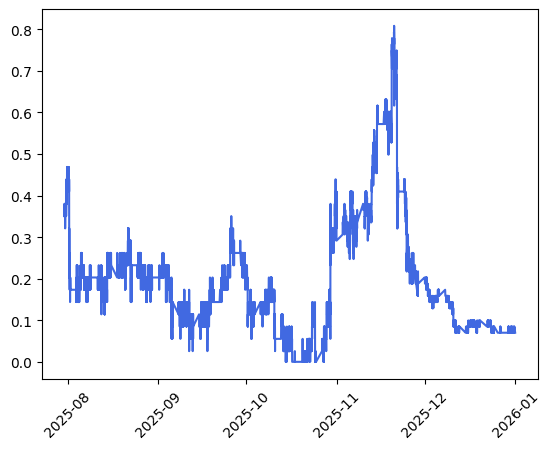

In [17]:
import matplotlib.pyplot as plt

plt.plot(imp_df["time"],imp_df['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()